In [2]:
import sys
!{sys.executable} -m pip install momentfm
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level upimport numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import logging
from pathlib import Path
from momentfm import MOMENTPipeline
import scipy
from sklearn.decomposition import PCA
#from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV #, MultiTaskLassoCV
#from celer import MultiTaskLassoCV
#from sklearn.metrics import mean_squared_error, r2_score

from clustering.moment import  get_activations_MOMENT
from clustering.utils import load_dataset
#from hough_scripts.separability import embeddings_pca_corr, lda_pca_embeddings, embeddings_umap


In [3]:
def extract_activations(dataset_path, model_type="moment", num_samples=20, device="cpu"):
    """
    Extract activations from a dataset for the specified model
    
    Parameters:
    -----------
    dataset_path : str
        Path to the parquet dataset
    model_type : str
        Model type ('moment' or 'chronos')
    num_samples : int
        Number of samples to use from the dataset
    device : str
        Device to run the model on ('cpu' or 'cuda')
        
    Returns:
    --------
    activations : numpy.ndarray
        The activations extracted from the model
    """
    logging.info(f"Extracting activations from {dataset_path} using {model_type} model")
    
    dataset = load_dataset(dataset_path, type="torch", device=device)

    if dataset.shape[0] > num_samples:
        logging.info(f"Limiting dataset from {dataset.shape[0]} to {num_samples} samples")
        dataset = dataset[:num_samples]

            
    if model_type.lower() == "moment":
        activations = get_activations_MOMENT(dataset, device=device)
        activations = activations.cpu().numpy() if device != "cpu" else activations.numpy()
        return activations
    
    elif model_type.lower() == "chronos":
        activations_encoder, activations_decoder = get_activations_Chronos(
            dataset.squeeze(1).cpu().numpy(), device=device
        )
        activations_encoder = activations_encoder.cpu().numpy() if device != "cpu" else activations_encoder.numpy()
        activations_decoder = activations_decoder.cpu().numpy() if device != "cpu" else activations_decoder.numpy()
        return activations_encoder
    
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

In [4]:
#Last layer activations, patch mean

def load_activations(path, model_type, num_samples, device):
    activations = extract_activations(path, model_type, num_samples, device)
    return np.mean(activations[23, :, :, :], axis=1)

In [5]:
#import umap.umap_ as umap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

num_samples=100
model_type="moment"
output_dir="results"
device="cpu"
n_transform=10

#path = "/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/clustering/datasets_clusters/"
path = "/mnt/c/Users/emika/OneDrive/Pulpit/Studia 4. rok/RISS//representations-in-tsfms-main/representations-in-tsfms-main/clustering/datasets_clusters/"

activations_trends = []
for ind in range(n_transform):
    dataset_path = os.path.join(path, "trends" + str(ind + 1) + ".parquet")
    activations_trends.append(load_activations(dataset_path, model_type, num_samples, device))
    
'''activations_sines = []
for ind in range(n_transform):
    dataset_path = os.path.join(path, "sines" + str(ind + 1 ) + ".parquet")
    activations_sines.append(load_activations(dataset_path, model_type, num_samples, device))

activations_exps = []
for ind in range(n_transform):
    dataset_path = os.path.join(path, "exps" + str(ind + 1) + ".parquet")
    activations_exps.append(load_activations(dataset_path, model_type, num_samples, device))
    print("activations loaded")'''



KeyboardInterrupt: 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#import umap.umap_ as umap

n_components = [2,5,10,50,100]

for n_c in n_components:

for activations in [activations_trends]:#[activations_trends, activations_sines, activations_exps]:
    combined = np.concatenate(activations, axis=0)
    reducer = PCA(n_components=2)
    #reducer = umap.UMAP( n_components=15,n_neighbors=10,min_dist=0.0,metric="euclidean",random_state=42)

    combined_reduced = reducer.fit_transform(combined)
    print(combined_reduced.shape)
    n = num_samples
    reduced_list = []
    
    for i in range(n_transform):
        reduced_list.append(combined_reduced[n*i:n*(i+1)])
        
    print(len(reduced_list))
    print(reduced_list[6].shape)
    X = np.vstack(reduced_list)
    n = reduced_list[0].shape[0]
    l = []
    for i in range(n_transform):
        l += [i] * n
    y = np.array(l)
    print(X.shape)
    print(y.shape)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


        
    



(1000, 2)
10
(100, 2)
(1000, 2)
(1000,)
Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       0.95      1.00      0.98        20
           6       1.00      0.95      0.97        20
           7       1.00      0.95      0.97        20
           8       0.51      1.00      0.68        20
           9       1.00      0.10      0.18        20

    accuracy                           0.90       200
   macro avg       0.95      0.90      0.88       200
weighted avg       0.95      0.90      0.88       200


Confusion Matrix:
 [[20  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0]
 [ 0  0  0

In [12]:
#reduce to 2 if embeddinngs are higher dimensional

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Split back to match reduced1..5
n = reduced1.shape[0]
reduced1 = X_pca[0:n]
reduced2 = X_pca[n:2*n]
reduced3 = X_pca[2*n:3*n]
reduced4 = X_pca[3*n:4*n]
reduced5 = X_pca[4*n:]

In [47]:
X_test.shape

(40, 2)

In [64]:
results_list = []
n=int(X_test.shape[0]/10)
for i in range(n_transform):
        results_list.append(X_test[n*i:n*(i+1)])

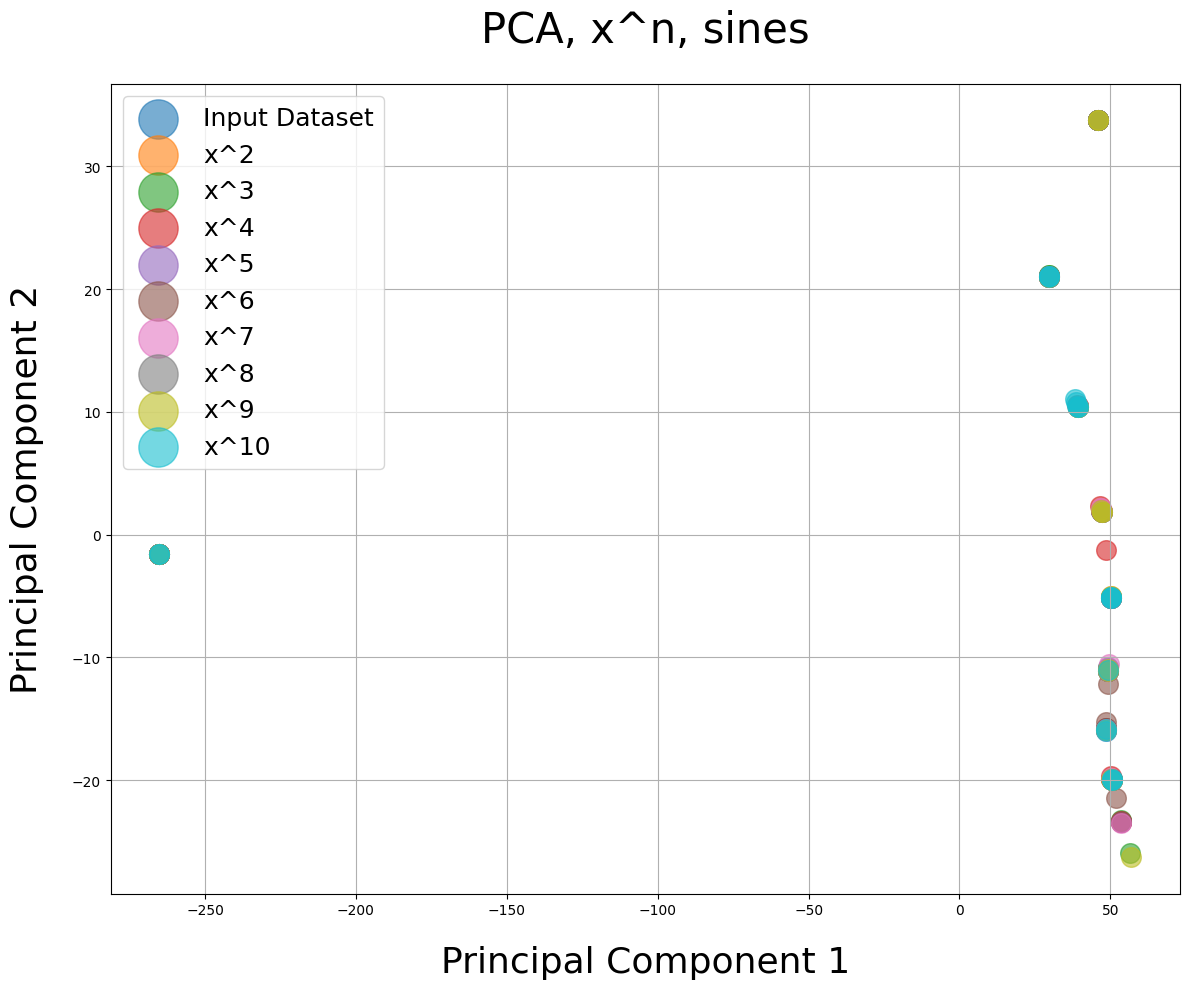

In [65]:
fig, ax = plt.subplots(figsize=(12, 10))

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]

# Labels for the legend
labels = ["Input Dataset", "x^2", "x^3", "x^4", "x^5", "x^6", "x^7", "x^8", "x^9", "x^10"]

# Corrected zip order: (data_array, color_string, label_string)
for reduced, color, label in zip(results_list, colors, labels):
    ax.scatter(reduced[:, 0], reduced[:, 1], c=color, label=label, alpha=0.6, s=200)

# Set titles and labels
ax.set_title("PCA, x^n, sines", fontsize=30, pad=30)
ax.set_xlabel("Principal Component 1", fontsize=26, labelpad=20)
ax.set_ylabel("Principal Component 2", fontsize=26, labelpad=20)

# The legend will now work because 'label' was passed to scatter
ax.legend(loc="best", fontsize=18, markerscale=2) 
ax.grid(True)

plt.tight_layout()
plt.show()